In [1]:
from google.colab import files
uploaded = files.upload()

Saving dataset.zip to dataset.zip


In [3]:
import zipfile
import os
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.applications import EfficientNetB0
import matplotlib.pyplot as plt

In [4]:
with zipfile.ZipFile('dataset.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/dataset')

In [5]:
os.listdir('/content/dataset/NEU-DET/train/images')

['inclusion',
 'patches',
 'pitted_surface',
 'crazing',
 'rolled-in_scale',
 'scratches']

In [6]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(rescale=1./255)

In [7]:
train_data = train_datagen.flow_from_directory(
    '/content/dataset/NEU-DET/train/images',
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    color_mode='rgb'
)

Found 1440 images belonging to 6 classes.


In [8]:
val_data = val_datagen.flow_from_directory(
    '/content/dataset/NEU-DET/validation/images',
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    color_mode='rgb'
)

Found 360 images belonging to 6 classes.


In [9]:
print(train_data.class_indices)
print(train_data.samples, val_data.samples)

{'crazing': 0, 'inclusion': 1, 'patches': 2, 'pitted_surface': 3, 'rolled-in_scale': 4, 'scratches': 5}
1440 360


In [10]:
# Base model of ResNET50
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224,224,3))

# Freeze layers
for layer in base_model.layers:
    layer.trainable = False

# Custom head
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
output = Dense(6, activation='softmax')(x)

model_resnet = Model(inputs=base_model.input, outputs=output)

# Compile model
model_resnet.compile(optimizer='adam',
                     loss='categorical_crossentropy',
                     metrics=['accuracy'])

# Training the model
resnet = model_resnet.fit(
    train_data,
    epochs=10,
    validation_data=val_data
)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 40s 586ms/step - accuracy: 0.1875 - loss: 1.8534 - val_accuracy: 0.2250 - val_loss: 1.7811
Epoch 2/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 20s 443ms/step - accuracy: 0.1965 - loss: 1.7922 - val_accuracy: 0.3083 - val_loss: 1.7276
Epoch 3/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 19s 413ms/step - accuracy: 0.2486 - loss: 1.7291 - val_accuracy: 0.2806 - val_loss: 1.7007
Epoch 4/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 20s 449ms/step - accuracy: 0.2771 - loss: 1.6978 - val_accuracy: 0.2556 - val_loss: 1.6683
Epoch 5/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 19s 414ms/step - accuracy: 0.2667 - loss: 1.6638 - val_accuracy: 0.3472 - val_loss: 1.6038
Epoch 6/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 20s 448ms/step - accuracy: 0.3292 - loss: 1.6214 - val_accuracy: 0.4111 - val_loss: 1.5475
Epoch 7/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 19s 419ms/step - accuracy: 0.3722 - loss: 1.5496 - val_accuracy: 0.3667 - val_loss: 1.5238
Epoch 8/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 20s 429m

In [11]:
#Base model InceptionV3
base_model = InceptionV3(weights='imagenet', include_top=False, input_shape=(224,224,3))

# Freeze Layers
for layer in base_model.layers:
    layer.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
output = Dense(6, activation='softmax')(x)

model_inception = Model(inputs=base_model.input, outputs=output)

# compile the model
model_inception.compile(optimizer='adam',
                        loss='categorical_crossentropy',
                        metrics=['accuracy'])
# model train
inception = model_inception.fit(
    train_data,
    epochs=10,
    validation_data=val_data
)

87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Epoch 1/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 48s 710ms/step - accuracy: 0.8729 - loss: 0.4220 - val_accuracy: 0.9417 - val_loss: 0.1954
Epoch 2/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 19s 411ms/step - accuracy: 0.9882 - loss: 0.0620 - val_accuracy: 0.9278 - val_loss: 0.2206
Epoch 3/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 19s 425ms/step - accuracy: 0.9868 - loss: 0.0534 - val_accuracy: 0.9389 - val_loss: 0.1894
Epoch 4/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 18s 409ms/step - accuracy: 0.9896 - loss: 0.0403 - val_accuracy: 0.9694 - val_loss: 0.1267
Epoch 5/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 19s 426ms/step - accuracy: 0.9910 - loss: 0.0314 - val_accuracy: 0.9667 - val_loss: 0.1078
Epoch 6/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 19s 417ms/step - accuracy: 0.9854 - loss: 0.0446 - val_accuracy: 0.9750 - val_loss: 0.0845
Epoch 7/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 20s 445ms/step - accuracy: 0.9896 - loss: 0.0341 - val_accuracy: 0.9472 - val_loss: 0.1759
Epoch 8/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 18s 405m

In [12]:
# Base model of EfficientNetB0
base_model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(224,224,3))

# Freeze Layers
for layer in base_model.layers:
    layer.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
output = Dense(6, activation='softmax')(x)

model_effnet = Model(inputs=base_model.input, outputs=output)

#Model compile
model_effnet.compile(optimizer='adam',
                     loss='categorical_crossentropy',
                     metrics=['accuracy'])
# model train
effnet = model_effnet.fit(
    train_data,
    epochs=10,
    validation_data=val_data
)

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 64s 818ms/step - accuracy: 0.1681 - loss: 1.8179 - val_accuracy: 0.1667 - val_loss: 1.7942
Epoch 2/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 19s 417ms/step - accuracy: 0.1521 - loss: 1.8019 - val_accuracy: 0.1667 - val_loss: 1.7952
Epoch 3/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 18s 391ms/step - accuracy: 0.1500 - loss: 1.7991 - val_accuracy: 0.1667 - val_loss: 1.8008
Epoch 4/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 19s 411ms/step - accuracy: 0.1542 - loss: 1.7996 - val_accuracy: 0.1667 - val_loss: 1.7925
Epoch 5/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 18s 390ms/step - accuracy: 0.1521 - loss: 1.7994 - val_accuracy: 0.1667 - val_loss: 1.7919
Epoch 6/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 17s 388ms/step - accuracy: 0.1549 - loss: 1.7963 - val_accuracy: 0.1667 - val_loss: 1.7973
Epoch 7/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 19s 412ms/step - accuracy: 0.1583 - loss: 1.7937 - val_accuracy: 0.1667 - val_loss: 1.7918
Epoch 8/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 18s 396m

In [13]:
print("ResNet Accuracy:", resnet.history['val_accuracy'][-1])
print("Inception Accuracy:", inception.history['val_accuracy'][-1])
print("EfficientNet Accuracy:", effnet.history['val_accuracy'][-1])

ResNet Accuracy: 0.3305555582046509
Inception Accuracy: 0.9666666388511658
EfficientNet Accuracy: 0.1666666716337204


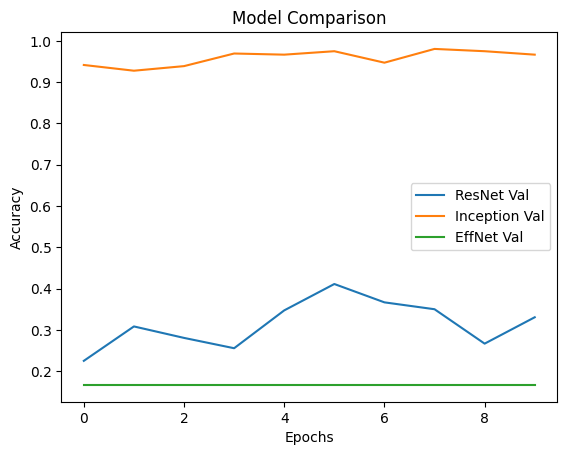

In [17]:
plt.plot(resnet.history['val_accuracy'], label='ResNet Val')

plt.plot(inception.history['val_accuracy'], label='Inception Val')
plt.plot(effnet.history['val_accuracy'], label='EffNet Val')

plt.legend()
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Model Comparison")
plt.show()

In [15]:
print("ResNet Loss:", resnet.history['val_loss'][-1])
print("Inception Loss:", inception.history['val_loss'][-1])
print("EfficientNet Loss:", effnet.history['val_loss'][-1])

ResNet Loss: 1.42822265625
Inception Loss: 0.09756296873092651
EfficientNet Loss: 1.7917687892913818


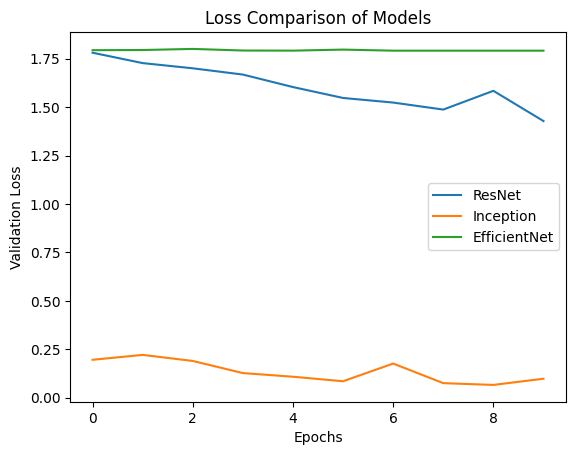

In [16]:
# ResNet
plt.plot(resnet.history['val_loss'], label='ResNet')

# Inception
plt.plot(inception.history['val_loss'], label='Inception')

# EfficientNet
plt.plot(effnet.history['val_loss'], label='EfficientNet')

plt.xlabel("Epochs")
plt.ylabel("Validation Loss")
plt.title("Loss Comparison of Models")
plt.legend()
plt.show()